# Importacion Conjunto Datos

Instalacion de Librerias

In [ ]:
!pip install yfinance


In [ ]:
!pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 13.1 MB/s eta 0:00:00


In [ ]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=f9b42232b72a72868369ca223b087eebf77f0ee7ccbb4b6dbb43638b8bd239b3
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
!pip install ydata_profiling

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.3/399.3 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.8 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2


In [ ]:
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import os
from sklearn.decomposition import PCA # Import PCA from sklearn.decomposition
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ta.trend import SMAIndicator, EMAIndicator
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands
from ta.trend import ADXIndicator

from ydata_profiling import ProfileReport


Funcion para descargar datos de Yahoo Finance

In [ ]:
#vamos a crear una funcion para descargar los datos del oro desde 1/9/2000
def descargar_datos_activo(activo, start_date, end_date, intervalo="1d"):
  # Descargar datos para el activo
  data = yf.download(activo, start=start_date, end=end_date, interval=intervalo)
  return data

In [ ]:
oro_2000 = descargar_datos_activo("GC=F", "2000-01-09", "2025-05-22")

[*********************100%***********************]  1 of 1 completed


In [ ]:
#verficamos que los datos se haan descargado desde y hastalas fechas etablecidas
oro_2000.head(-5)

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2000-08-30,273.899994,273.899994,273.899994,273.899994,0
2000-08-31,278.299988,278.299988,274.799988,274.799988,0
2000-09-01,277.000000,277.000000,277.000000,277.000000,0
2000-09-05,275.799988,275.799988,275.799988,275.799988,2
2000-09-06,274.200012,274.200012,274.200012,274.200012,0
...,...,...,...,...,...
2025-05-08,3296.600098,3390.000000,3288.699951,3390.000000,200
2025-05-09,3335.399902,3335.500000,3299.000000,3299.000000,216


In [ ]:
#observamos la forma del df
oro_2000.shape

(6203, 5)

In [ ]:
oro_2000.columns


MultiIndex([( 'Close', 'GC=F'),
            (  'High', 'GC=F'),
            (   'Low', 'GC=F'),
            (  'Open', 'GC=F'),
            ('Volume', 'GC=F')],
           names=['Price', 'Ticker'])

In [ ]:
#eliminamos el multinivel del DF y verificamos
oro_2000.columns = oro_2000.columns.droplevel(1)
oro_2000.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2000-08-30,273.899994,273.899994,273.899994,273.899994,0
2000-08-31,278.299988,278.299988,274.799988,274.799988,0
2000-09-01,277.000000,277.000000,277.000000,277.000000,0
2000-09-05,275.799988,275.799988,275.799988,275.799988,2
2000-09-06,274.200012,274.200012,274.200012,274.200012,0


In [ ]:
#reseteamos el indice para que se tome el Date y verificamos
oro_2000= oro_2000.reset_index()
oro_2000 = oro_2000.set_index('Date')  # Establece "Date" como índice
oro_2000.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2000-08-30,273.899994,273.899994,273.899994,273.899994,0
2000-08-31,278.299988,278.299988,274.799988,274.799988,0
2000-09-01,277.000000,277.000000,277.000000,277.000000,0
2000-09-05,275.799988,275.799988,275.799988,275.799988,2
2000-09-06,274.200012,274.200012,274.200012,274.200012,0


In [ ]:
# Verificamos que el indice sea del tipo DatetimeIndex
print(oro_2000.index)

DatetimeIndex(['2000-08-30', '2000-08-31', '2000-09-01', '2000-09-05',
               '2000-09-06', '2000-09-07', '2000-09-08', '2000-09-11',
               '2000-09-12', '2000-09-13',
               ...
               '2025-05-08', '2025-05-09', '2025-05-12', '2025-05-13',
               '2025-05-14', '2025-05-15', '2025-05-16', '2025-05-19',
               '2025-05-20', '2025-05-21'],
              dtype='datetime64[ns]', name='Date', length=6203, freq=None)


In [ ]:
#verificamos el tipo de DF
print(type(oro_2000))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
#verificamos la existencia de nuls
print(oro_2000.isnull().values.any())

False


In [ ]:
#analisis del DF
oro_2000.describe()

Price,Close,High,Low,Open,Volume
count,6203.000000,6203.000000,6203.000000,6203.000000,6203.000000
mean,1189.853603,1195.905288,1183.618636,1189.868193,4284.007255
std,620.323337,623.929038,616.528038,620.193901,24231.992176
min,255.100006,256.100006,255.000000,255.000000,0.000000
25%,637.850006,641.549988,635.350006,640.100006,21.500000
50%,1240.000000,1245.000000,1233.900024,1239.400024,110.000000
75%,1645.599976,1657.900024,1636.350037,1646.750000,418.000000
max,3411.399902,3485.600098,3364.699951,3422.199951,386334.000000


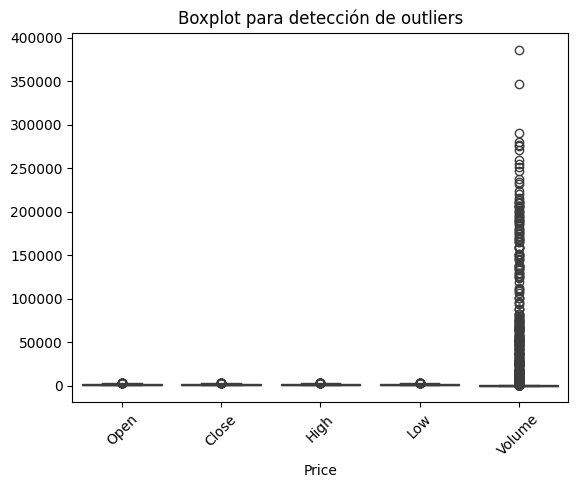

In [ ]:
sns.boxplot(data=oro_2000[['Open', 'Close', 'High', 'Low', 'Volume']])
plt.xticks(rotation=45)
plt.title('Boxplot para detección de outliers')
plt.show()

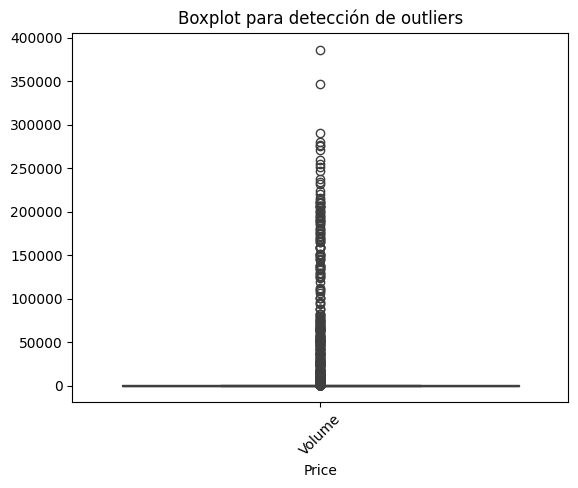

In [ ]:
sns.boxplot(data=oro_2000[['Volume']])
plt.xticks(rotation=45)
plt.title('Boxplot para detección de outliers')
plt.show()

In [ ]:
# 1. Calcular ADX y su pendiente
adx_indicator = ADXIndicator(
    high=oro_2000['High'],
    low=oro_2000['Low'],
    close=oro_2000['Close'],
    window=14
)
oro_2000['ADX'] = adx_indicator.adx()  # Fuerza de la tendencia
oro_2000['ADX_Pos'] = adx_indicator.adx_pos()  # DI+ (tendencia alcista)
oro_2000['ADX_Neg'] = adx_indicator.adx_neg()  # DI- (tendencia bajista)

# 2. Calcular pendiente del ADX (comparado con vela anterior)
oro_2000['pend_ADX'] = np.where(
    oro_2000['ADX'] > oro_2000['ADX'].shift(1),
    1,  # Pendiente positiva (ADX subiendo)
    -1  # Pendiente negativa (ADX bajando)
)

# 3. Señales de Compra/Venta basadas en ADX y su pendiente
oro_2000['signal'] = np.where(
    oro_2000['pend_ADX'] == 1,  # Si ADX tiene pendiente positiva
    1,  # Señal de COMPRA
    -1  # Señal de VENTA (o no entrar)
)

In [ ]:
# Indicadores técnicos
oro_2000['EMA_55'] = EMAIndicator(close=oro_2000['Close'], window=55).ema_indicator()
oro_2000['EMA_10'] = EMAIndicator(close=oro_2000['Close'], window=10).ema_indicator()
bb = BollingerBands(close=oro_2000['Close'], window=20)
oro_2000['BB_High'] = bb.bollinger_hband()
oro_2000['BB_Low'] = bb.bollinger_lband()


In [ ]:
# 2. Crear un nuevo DataFrame sin NaN que se generan en coluimnas con media
oro_2000_clean = oro_2000.dropna().copy()

In [ ]:
# 3. Estandarización solo desde el primer registro completo


cols_numericas = oro_2000_clean.select_dtypes(include='number').columns
scaler = StandardScaler()
oro_std_scaled = pd.DataFrame(scaler.fit_transform(oro_2000_clean[cols_numericas]),
                               columns=cols_numericas,
                               index=oro_2000_clean.index)


In [ ]:
oro_std_scaled.head()

Price,Close,High,Low,Open,Volume,ADX,ADX_Pos,ADX_Neg,pend_ADX,signal,EMA_55,EMA_10,BB_High,BB_Low
Date,,,,,,,,,,,,,,
2000-11-15,-1.511997,-1.513106,-1.511038,-1.512341,-0.177572,-0.092950,0.100576,1.830954,-0.948781,-0.948781,-1.516863,-1.514461,-1.522795,-1.504584
2000-11-16,-1.510863,-1.511978,-1.509896,-1.511206,-0.177449,-0.195319,0.393267,1.589637,-0.948781,-0.948781,-1.517059,-1.514237,-1.523806,-1.504230
2000-11-17,-1.511025,-1.512139,-1.510875,-1.512178,-0.177285,-0.251695,0.251068,1.838897,-0.948781,-0.948781,-1.517253,-1.514083,-1.525587,-1.503258
2000-11-20,-1.510052,-1.511172,-1.509081,-1.510395,-0.177572,-0.353927,0.508250,1.620591,-0.948781,-0.948781,-1.517405,-1.513780,-1.527057,-1.502329
2000-11-21,-1.511025,-1.512139,-1.510059,-1.511368,-0.177572,-0.408356,0.353207,1.881060,-0.948781,-0.948781,-1.517587,-1.513709,-1.529366,-1.500607


In [ ]:
profile=ProfileReport(oro_2000) #se genera
profile.to_file('Profilling.html') #se exporta para no cargar el colab

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 32.61it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#verificamos laconsistencia dle df oro_2000_scaled
oro_std_scaled.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6149 entries, 2000-11-15 to 2025-05-21
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Close     6149 non-null   float64
 1   High      6149 non-null   float64
 2   Low       6149 non-null   float64
 3   Open      6149 non-null   float64
 4   Volume    6149 non-null   float64
 5   ADX       6149 non-null   float64
 6   ADX_Pos   6149 non-null   float64
 7   ADX_Neg   6149 non-null   float64
 8   pend_ADX  6149 non-null   float64
 9   signal    6149 non-null   float64
 10  EMA_55    6149 non-null   float64
 11  EMA_10    6149 non-null   float64
 12  BB_High   6149 non-null   float64
 13  BB_Low    6149 non-null   float64
dtypes: float64(14)
memory usage: 720.6 KB


In [ ]:
oro_std_scaled.isnull().sum()

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0
ADX,0
ADX_Pos,0
ADX_Neg,0
pend_ADX,0


In [ ]:
#escalamos los datos Conforme cap 14 Nielsen

#creamos una copia del df del oro original solo con datos de YF
oro_scaled_Nielsen = oro_2000[['Close','Open', 'High', 'Low', 'Volume']].copy()


# Primero calculamos los retornos diarios y volatilidad
oro_scaled_Nielsen['Return'] = oro_scaled_Nielsen['Close'] - oro_scaled_Nielsen['Open']
oro_scaled_Nielsen['DailyVolatility'] = oro_scaled_Nielsen['High']-oro_scaled_Nielsen['Low']  # Volatilidad diaria

# Parámetro de suavizado (half-life)
halflife = 10

# Seleccionar solo las columnas numéricas para EWMA calculation
numeric_cols = oro_scaled_Nielsen.select_dtypes(include=np.number).columns

# 1. Calcular medias móviles exponenciales (EWMA)
ewma = oro_scaled_Nielsen[numeric_cols].ewm(halflife=halflife).mean()

# 2. Calcular varianzas móviles exponenciales
ewvar = oro_scaled_Nielsen[numeric_cols].ewm(halflife=halflife).var()

oro_scaled_Nielsen['ScaledVolatility'] = ((oro_scaled_Nielsen.DailyVolatility - ewma.DailyVolatility) / (ewvar.DailyVolatility**0.5))
oro_scaled_Nielsen['ScaledReturn'] = ((oro_scaled_Nielsen.Return - ewma.Return) / (ewvar.Return**0.5))
oro_scaled_Nielsen['ScaledVolume'] = ((oro_scaled_Nielsen.Volume - ewma.Volume) / (ewvar.Volume**0.5))


# Eliminar NaN (resultado de los cálculos móviles)
oro_scaled_Nielsen = oro_scaled_Nielsen.dropna()

# Ver resultados
print(oro_scaled_Nielsen[['Close', 'ScaledReturn', 'ScaledVolume', 'ScaledVolatility']].head(10))

Price            Close  ScaledReturn  ScaledVolume  ScaledVolatility
Date                                                                
2000-09-05  275.799988     -0.487191      1.399270         -0.487191
2000-09-06  274.200012     -0.426635     -0.465213         -0.426635
2000-09-07  274.000000     -0.381686      1.841310         -0.381686
2000-09-08  273.299988     -0.346452     -0.413957         -0.346452
2000-09-11  273.100006     -0.317772     -0.377947         -0.317772
2000-09-12  272.899994     -0.293775     -0.348220         -0.293775
2000-09-13  272.799988     -0.273266     -0.323069         -0.273266
2000-09-14  272.399994     -0.255444     -0.301379         -0.255444
2000-09-15  272.299988     -0.239748     -0.282391         -0.239748
2000-09-18  271.399994     -0.225770     -0.265564         -0.225770


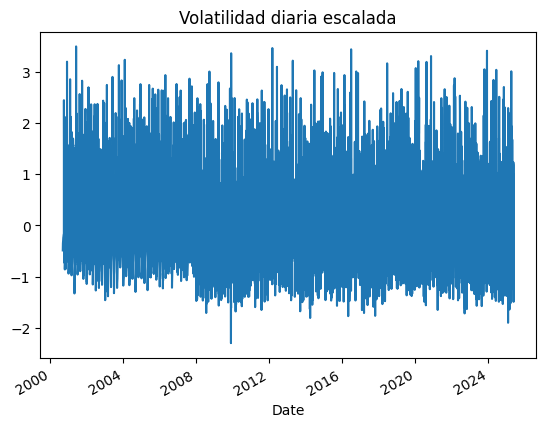

In [ ]:
#gtraficamos la volatilidad diaria a ls efects de verificar estacionariedad
scaled = oro_scaled_Nielsen.DailyVolatility - ewma.DailyVolatility
scaled = scaled / ewvar.DailyVolatility**0.5
scaled.plot()
plt.title('Volatilidad diaria escalada')
plt.savefig('Volatilidad diaria escalada.png')
plt.show()


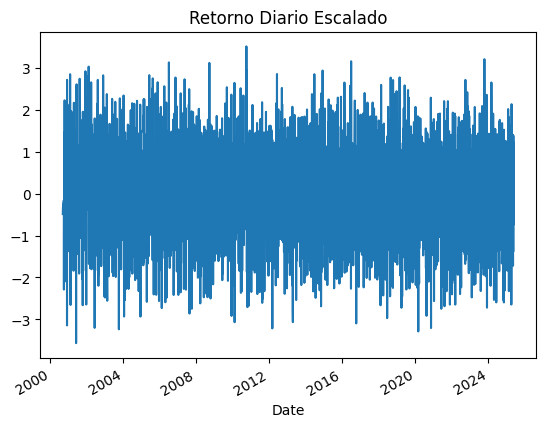

In [ ]:
#gtraficamos la el retorno diario escalado a ls efects de verificar estacionariedad
scaled = oro_scaled_Nielsen.Return - ewma.Return
scaled = scaled / ewvar.Return**0.5
scaled.plot()
plt.title('Retorno Diario Escalado')
plt.savefig('Retorno diario escalado.png')
plt.show()

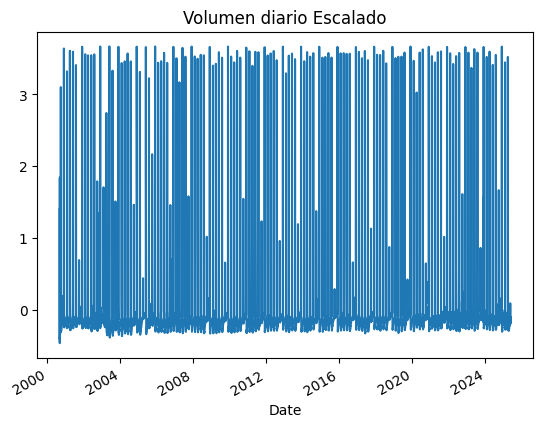

In [ ]:
#gtraficamos el volumen escalado diario a ls efects de verificar estacionariedad
scaled = oro_scaled_Nielsen.Volume - ewma.Volume
scaled = scaled / ewvar.Volume**0.5
scaled.plot()
plt.title('Volumen diario Escalado')
plt.savefig('Volumen diario escalado.png')
plt.show()

Visualmente las series parecen estacionarias (en media y varianza estables en el tiempo).

#Random Forest

In [ ]:
#copiamos los df que usaremos, para aplicar xgb utilizaremos un df std y uno no std
oro_rf = oro_2000_clean.copy()
oro_rf_std = oro_std_scaled.copy()
oro_rf_nielsen = oro_scaled_Nielsen.copy()

In [ ]:
#debemos definir la variable objetivo, definiremos 2, el precio de mañana y si el precio de mañana sera mayor o menos al de hoy
oro_rf['Target'] = (oro_rf['Close'].shift(-1) > oro_rf['Close']).astype(int)
oro_rf['Close + 1'] = oro_rf['Close'].shift(-1)
oro_rf.head()

Price,Close,High,Low,Open,Volume,ADX,ADX_Pos,ADX_Neg,pend_ADX,signal,EMA_55,EMA_10,BB_High,BB_Low,Target,Close + 1
Date,,,,,,,,,,,,,,,,
2000-11-15,265.100006,265.100006,265.100006,265.100006,0,23.090331,33.302461,47.153399,-1,-1,269.104288,265.041710,270.508312,261.241685,1,265.799988
2000-11-16,265.799988,265.799988,265.799988,265.799988,3,22.130716,36.807591,44.675364,-1,-1,268.986277,265.179579,269.868760,261.451235,0,265.700012
2000-11-17,265.700012,265.700012,265.200012,265.200012,7,21.602237,35.104684,47.234964,-1,-1,268.868911,265.274203,268.742549,262.027446,1,266.299988
2000-11-20,266.299988,266.299988,266.299988,266.299988,0,20.643910,38.184573,44.993224,-1,-1,268.777164,265.460709,267.812233,262.577760,0,265.700012
2000-11-21,265.700012,265.700012,265.700012,265.700012,0,20.133685,36.327854,47.667920,-1,-1,268.667265,265.504219,266.351774,263.598220,1,266.299988


In [ ]:
# Crear lags (valores pasados)
def create_lags(df, column="Close", lags=5):
    for lag in range(1, lags + 1):
        df[f"Lag_{lag}"] = df[column].shift(lag)
    return df

# Aplicamos al DF
oro_rf = create_lags(oro_rf, lags=20)  # Usamos los últimos 20 días
oro_rf = oro_rf.dropna()

In [ ]:
#verificamos el tamaño de nuestro DF para tomar datos de entrenamiento y prueba
oro_rf.shape

(6128, 36)

In [ ]:
#verificamos las columnas
oro_rf.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'ADX', 'ADX_Pos', 'ADX_Neg',
       'pend_ADX', 'signal', 'EMA_55', 'EMA_10', 'BB_High', 'BB_Low', 'Target',
       'Close + 1', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Lag_5', 'Lag_6',
       'Lag_7', 'Lag_8', 'Lag_9', 'Lag_10', 'Lag_11', 'Lag_12', 'Lag_13',
       'Lag_14', 'Lag_15', 'Lag_16', 'Lag_17', 'Lag_18', 'Lag_19', 'Lag_20'],
      dtype='object', name='Price')

In [ ]:
oro_rf.shape

(6128, 36)

In [ ]:
#reducimos la dimensionalidad del DF para poder correr el modelo
# y definimos X e y  (features y target)
X_rf = oro_rf.iloc[-1260:].drop(["Target", "Close + 1"], axis=1)  # Eliminar columnas no usadas
y_rf = oro_rf.iloc[-1260:]["Close + 1"]  # Predecir el precio directamente

In [ ]:
test_size_rf = int(len(X_rf) * 0.2)  # 20% para test (últimos datos)
X_rf_train, X_rf_test = X_rf.iloc[:-test_size_rf], X_rf.iloc[-test_size_rf:]
y_rf_train, y_rf_test = y_rf.iloc[:-test_size_rf], y_rf.iloc[-test_size_rf:]

In [ ]:
from sklearn.ensemble import RandomForestRegressor


total_datos = 1260
train_size_rf = 1008
test_size_rf = 252

# Listas para almacenar resultados
predicciones = []
indices_test = []

# Modelo (Use random state para poder replicar el modelo)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Ciclo de backtesting
for i in range(train_size_rf, total_datos):
    # Definir ventana de entrenamiento y dato a predecir
    X_rf_train_window = X_rf.iloc[i-train_size_rf:i]
    y_rf_train_window = y_rf.iloc[i-train_size_rf:i]
    X_rf_test_point = X_rf.iloc[[i]]  # El siguiente dato a predecir (como DataFrame)

    # Entrenar y predecir
    model_rf.fit(X_rf_train_window, y_rf_train_window)
    pred = model_rf.predict(X_rf_test_point)[0]

    # Guardar resultados
    predicciones.append(pred)
    indices_test.append(y_rf.index[i])  # Guardar el índice



In [ ]:
# Crear DataFrame con resultados
resultados_backtest = pd.DataFrame({
    'Índice': indices_test,
    'Valor_Real': y_rf.iloc[-test_size_rf:].values,
    'Predicción': predicciones
}).set_index('Índice')

In [ ]:
# Calcular métricas
from sklearn.metrics import mean_absolute_error, r2_score

mae_rf = mean_absolute_error(resultados_backtest['Valor_Real'], resultados_backtest['Predicción'])
r2_rf = r2_score(resultados_backtest['Valor_Real'], resultados_backtest['Predicción'])

print(f"MAE_rf: {mae_rf:.4f}")
print(f"R²: {r2_rf:.4f}")
print("\nResultados:")
print(resultados_backtest.head(-5))

MAE_rf: 31.6546
R²: 0.9781

Resultados:
             Valor_Real   Predicción
Índice                              
2024-05-20  2421.699951  2379.537954
2024-05-21  2389.199951  2404.468948
2024-05-22  2335.000000  2393.543953
2024-05-23  2332.500000  2344.185981
2024-05-24  2355.199951  2343.762981
...                 ...          ...
2025-05-07  3296.600098  3326.489961
2025-05-08  3335.399902  3301.130010
2025-05-09  3220.000000  3315.244988
2025-05-12  3240.300049  3254.102981
2025-05-13  3181.399902  3258.038003

[247 rows x 2 columns]


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_real_vs_predicted(
    df: pd.DataFrame,
    real_col: str = 'Valor_Real',
    pred_col: str = 'Predicción',
    title: str = 'Precio Real vs Predicho del Oro (Random Forest)',
    real_color: str = 'blue',
    pred_color: str = 'red',
    pred_linestyle: str = '--',
    figsize: tuple = (12, 6),
    grid: bool = True,
    save_path: str = None
) -> None:
    plt.figure(figsize=figsize)
    plt.plot(df.index, df[real_col], label='Real', color=real_color, linewidth=1.5)
    plt.plot(df.index, df[pred_col], label='Predicción', color=pred_color, linestyle=pred_linestyle, alpha=0.8)

    plt.title(title, fontsize=14, pad=20)
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Precio', fontsize=12)
    plt.legend(fontsize=10, framealpha=1)

    if grid:
        plt.grid(True, linestyle='--', alpha=0.6)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

# Uso ejemplo:
# plot_real_vs_predicted(resultados_backtest, title='Mi Título Personalizado', pred_color='green')

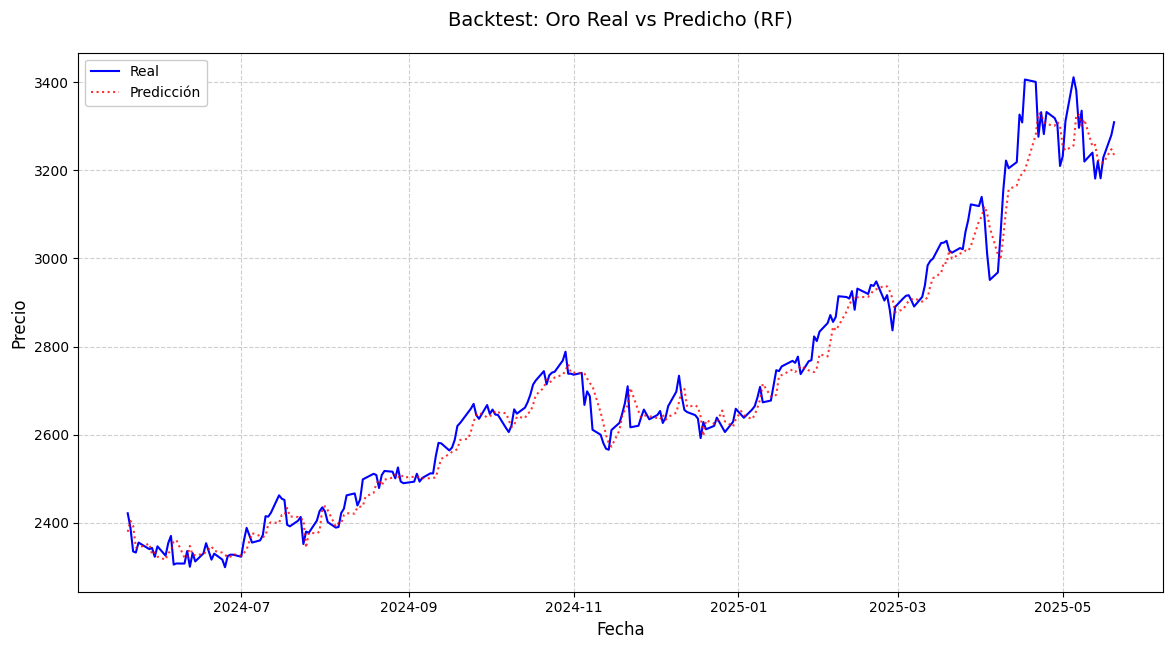

In [ ]:
plot_real_vs_predicted(
    df=resultados_backtest,
    real_col='Valor_Real',
    pred_col='Predicción',
    title='Backtest: Oro Real vs Predicho (RF)',
    real_color='b',  # Azul matplotlib
    pred_color='r',  # Rojo matplotlib
    pred_linestyle=':',
    figsize=(14, 7),
    save_path='backtest_oro_rf.png'
)

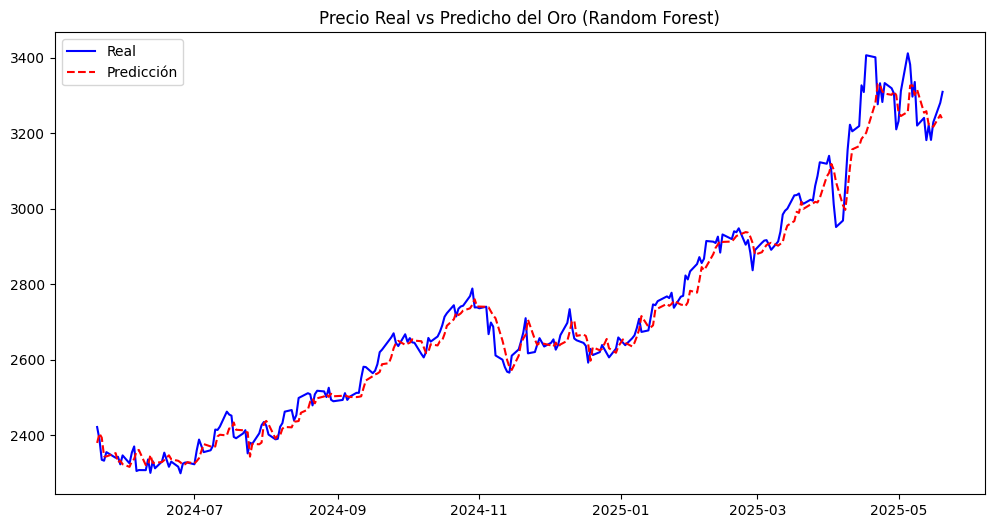

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(resultados_backtest.index, resultados_backtest['Valor_Real'], label='Real', color='blue')
plt.plot(resultados_backtest.index, resultados_backtest['Predicción'], label='Predicción', color='red', linestyle='--')
plt.title('Precio Real vs Predicho del Oro (Random Forest)')
plt.legend()
plt.show()

In [ ]:
#-----------BACKTESTING
# -- PASO 1: Preparar los DataFrames --
# Asegurarse de que los índices de ambos DataFrames coincidan (fechas)
resultados_backtest = resultados_backtest.sort_index()
oro_rf = oro_rf.sort_index()

# Extraer el precio Close original del df oro_rf (solo las fechas relevantes)
close_original = oro_rf.loc[resultados_backtest.index, 'Close'].shift(-1) #traer el valor del dia siguiente poreu para la fecha n la prediccion es de n+1

# -- PASO 2: Calcular señales y rentabilidad --
df_rentabilidad = resultados_backtest.copy()
df_rentabilidad['Close_Original'] = close_original  # Añadir columna con precio real
df_rentabilidad['Valor_Dia_Ant'] = close_original.shift(1)  # para comparar con pred y verificar si corresponde entrar

# Calcular retornos diarios reales (usando Close_Original para precisión)
df_rentabilidad['Retorno_Real'] = df_rentabilidad['Close_Original'].pct_change()

# Señal de trading: Compra si Predicción > Close del día anterior
df_rentabilidad['Señal'] = np.where(
    df_rentabilidad['Predicción'] > df_rentabilidad['Close_Original'].shift(1),
    1,  # Comprar
    0   # No operar
)

# Retorno de la estrategia (solo días con señal=1)
df_rentabilidad['Retorno_Estrategia'] = df_rentabilidad['Señal'] * df_rentabilidad['Retorno_Real']

# -- PASO 3: Métricas clave --
# Rentabilidad acumulada
df_rentabilidad['Rentabilidad_Acumulada'] = (1 + df_rentabilidad['Retorno_Estrategia']).cumprod() - 1

# Estadísticas
rentabilidad_final = df_rentabilidad['Rentabilidad_Acumulada'].iloc[-1] * 100
num_operaciones = df_rentabilidad['Señal'].sum()
operaciones_positivas = (df_rentabilidad['Retorno_Estrategia'] > 0).sum()
accuracy = operaciones_positivas / num_operaciones if num_operaciones > 0 else 0

# -- RESULTADOS --
print(f"\nRentabilidad Final: {rentabilidad_final:.2f}%")
print(f"Número de Operaciones: {num_operaciones}")
print(f"Operaciones Positivas: {operaciones_positivas}")
print(f"Accuracy: {accuracy:.2%}")

# Mostrar tabla con datos relevantes
columnas_mostrar = ['Close_Original', 'Valor_Real', 'Predicción','Valor_Dia_Ant', 'Señal', 'Retorno_Real', 'Retorno_Estrategia']
print("\nDetalle de Operaciones:")
print(df_rentabilidad[columnas_mostrar].tail(-10))


Rentabilidad Final: 27.83%
Número de Operaciones: 100
Operaciones Positivas: 62
Accuracy: 62.00%

Detalle de Operaciones:
            Close_Original   Valor_Real   Predicción  Valor_Dia_Ant  Señal  \
Índice                                                                       
2024-06-04     2354.100098  2354.100098  2331.192004    2325.500000      1   
2024-06-05     2370.300049  2370.300049  2336.968000    2354.100098      0   
2024-06-06     2305.199951  2305.199951  2357.567012    2370.300049      0   
2024-06-07     2307.699951  2307.699951  2361.027991    2305.199951      1   
2024-06-10     2307.500000  2307.500000  2320.893992    2307.699951      1   
...                    ...          ...          ...            ...    ...   
2025-05-14     3220.699951  3220.699951  3222.673958    3181.399902      1   
2025-05-15     3182.000000  3182.000000  3223.364966    3220.699951      1   
2025-05-16     3228.899902  3228.899902  3216.766973    3182.000000      1   
2025-05-19     3280

<ipython-input-422-111cb2618d55>:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_rentabilidad['Retorno_Real'] = df_rentabilidad['Close_Original'].pct_change()


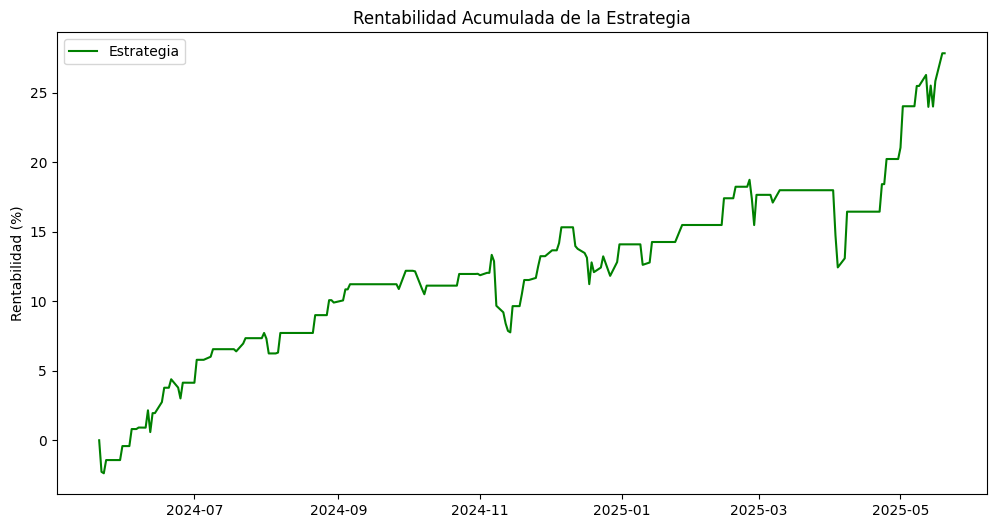

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_rentabilidad.index, df_rentabilidad['Rentabilidad_Acumulada'] * 100, label='Estrategia', color='green')
plt.title('Rentabilidad Acumulada de la Estrategia')
plt.ylabel('Rentabilidad (%)')
plt.legend()
plt.show()

# GradientBoostingRegressor

In [ ]:
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
import seaborn as sns
import statsmodels.api as sm #Nos permite acceder al conjunto de datos y realizar regresión lineal
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
import joblib


In [ ]:
#copiamos los df que usaremos, para aplicar xgb utilizaremos un df std y uno no std
oro_xgb = oro_2000_clean.copy()
oro_xgb_std = oro_std_scaled.copy()

In [ ]:
oro_xgb.head()

Price,Close,High,Low,Open,Volume,ADX,ADX_Pos,ADX_Neg,pend_ADX,signal,EMA_55,EMA_10,BB_High,BB_Low
Date,,,,,,,,,,,,,,
2000-11-15,265.100006,265.100006,265.100006,265.100006,0,23.090331,33.302461,47.153399,-1,-1,269.104288,265.041710,270.508312,261.241685
2000-11-16,265.799988,265.799988,265.799988,265.799988,3,22.130716,36.807591,44.675364,-1,-1,268.986277,265.179579,269.868760,261.451235
2000-11-17,265.700012,265.700012,265.200012,265.200012,7,21.602237,35.104684,47.234964,-1,-1,268.868911,265.274203,268.742549,262.027446
2000-11-20,266.299988,266.299988,266.299988,266.299988,0,20.643910,38.184573,44.993224,-1,-1,268.777164,265.460709,267.812233,262.577760
2000-11-21,265.700012,265.700012,265.700012,265.700012,0,20.133685,36.327854,47.667920,-1,-1,268.667265,265.504219,266.351774,263.598220


## DF sin Escalar

In [ ]:
#debemos definir la variable objetivo, definiremos 2, el precio de mañana y si el precio de mañana sera mayor o menos al de hoy
oro_xgb['Target'] = (oro_xgb['Close'].shift(-1) > oro_xgb['Close']).astype(int)
oro_xgb['Close + 1'] = oro_xgb['Close'].shift(-1)
oro_xgb.head()

Price,Close,High,Low,Open,Volume,ADX,ADX_Pos,ADX_Neg,pend_ADX,signal,EMA_55,EMA_10,BB_High,BB_Low,Target,Close + 1
Date,,,,,,,,,,,,,,,,
2000-11-15,265.100006,265.100006,265.100006,265.100006,0,23.090331,33.302461,47.153399,-1,-1,269.104288,265.041710,270.508312,261.241685,1,265.799988
2000-11-16,265.799988,265.799988,265.799988,265.799988,3,22.130716,36.807591,44.675364,-1,-1,268.986277,265.179579,269.868760,261.451235,0,265.700012
2000-11-17,265.700012,265.700012,265.200012,265.200012,7,21.602237,35.104684,47.234964,-1,-1,268.868911,265.274203,268.742549,262.027446,1,266.299988
2000-11-20,266.299988,266.299988,266.299988,266.299988,0,20.643910,38.184573,44.993224,-1,-1,268.777164,265.460709,267.812233,262.577760,0,265.700012
2000-11-21,265.700012,265.700012,265.700012,265.700012,0,20.133685,36.327854,47.667920,-1,-1,268.667265,265.504219,266.351774,263.598220,1,266.299988


In [ ]:
# Crear lags (valores pasados)
def create_lags(df, column="Close", lags=5):
    for lag in range(1, lags + 1):
        df[f"Lag_{lag}"] = df[column].shift(lag)
    return df

# Aplicar a tus datos
oro_xgb = create_lags(oro_xgb, lags=20)  # Usamos los últimos 20 días
oro_xgb = oro_xgb.dropna()

In [ ]:
#verificamos el tamaño de nuestro DF para tomar datos de entrenamiento y prueba
oro_xgb.shape

(6128, 36)

In [ ]:
#verificamos las columnas
oro_xgb.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'ADX', 'ADX_Pos', 'ADX_Neg',
       'pend_ADX', 'signal', 'EMA_55', 'EMA_10', 'BB_High', 'BB_Low', 'Target',
       'Close + 1', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Lag_5', 'Lag_6',
       'Lag_7', 'Lag_8', 'Lag_9', 'Lag_10', 'Lag_11', 'Lag_12', 'Lag_13',
       'Lag_14', 'Lag_15', 'Lag_16', 'Lag_17', 'Lag_18', 'Lag_19', 'Lag_20'],
      dtype='object', name='Price')

In [ ]:
#reducimos la dimensionalidad del DF para poder correr el modelo, tomamos los ultimos 5 años considerando años de 252 dias habiles
X_xgb = oro_xgb.iloc[-1260:].drop(["Target", "Close + 1"], axis=1)  # Eliminar columnas no usadas
y_xgb = oro_xgb.iloc[-1260:]["Close + 1"]  # Predecir el precio de cierre del registro siguiente
feature_names = X_xgb.columns
feature_names

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'ADX', 'ADX_Pos', 'ADX_Neg',
       'pend_ADX', 'signal', 'EMA_55', 'EMA_10', 'BB_High', 'BB_Low', 'Lag_1',
       'Lag_2', 'Lag_3', 'Lag_4', 'Lag_5', 'Lag_6', 'Lag_7', 'Lag_8', 'Lag_9',
       'Lag_10', 'Lag_11', 'Lag_12', 'Lag_13', 'Lag_14', 'Lag_15', 'Lag_16',
       'Lag_17', 'Lag_18', 'Lag_19', 'Lag_20'],
      dtype='object', name='Price')

In [ ]:
test_size_xgb = int(len(X_xgb) * 0.2)  # 20% para test (últimos datos)
X_xgb_train, X_xgb_test = X_xgb.iloc[:-test_size_xgb], X_xgb.iloc[-test_size_xgb:]
y_xgb_train, y_xgb_test = y_xgb.iloc[:-test_size_xgb], y_xgb.iloc[-test_size_xgb:]

In [ ]:
def gradient_boost_temporal(
    data: pd.DataFrame,
    target_col: str,
    features: list,
    train_window: int = 1008,  # 4 años de datos (~252 días/año)
    test_size: int = 252,      # 1 año para test
    param_grid: dict = None,
    save_model: bool = False,
    model_name: str = 'gb_model.pkl'
) -> dict:
    # --- 1. Preparación de datos ---
    # Asegurar orden temporal
    data = data.sort_index()

    # Definir X e y
    X = data[features]
    y = data[target_col]

    # Índices para test (últimos 'test_size' días)
    test_start = len(X) - test_size
    X_test = X.iloc[test_start:]
    y_test = y.iloc[test_start:]

    # --- 2. Configuración del modelo ---
    if param_grid is None:
        param_grid = {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 5],
            'min_samples_split': [2, 5]
        }

    # Métricas para evaluación
    scoring = {
        'R2': 'r2',
        'MAE': 'neg_mean_absolute_error'
    }

    # --- 3. Entrenamiento con ventana móvil ---
    predictions = []
    actuals = []
    indices = []

    for i in range(test_start, len(X)):
        # Ventana de entrenamiento móvil
        X_train = X.iloc[i - train_window:i]
        y_train = y.iloc[i - train_window:i]

        # Búsqueda de hiperparámetros (solo en primera iteración para velocidad)
        if i == test_start:
            gbm = GradientBoostingRegressor(random_state=42)
            tscv = TimeSeriesSplit(n_splits=3)
            grid = GridSearchCV(gbm, param_grid, cv=tscv, scoring=scoring, refit='R2', n_jobs=-1)
            grid.fit(X_train, y_train)
            best_model = grid.best_estimator_
            print(f"\nMejores parámetros: {grid.best_params_}")
        else:
            # Reentrenar con nuevos datos
            best_model.fit(X_train, y_train)

        # Predecir siguiente punto
        pred = best_model.predict(X.iloc[[i]])[0]
        predictions.append(pred)
        actuals.append(y.iloc[i])
        indices.append(y.index[i])

    # --- 4. Resultados ---
    results_df = pd.DataFrame({
        'Actual': actuals,
        'Predicted': predictions
    }, index=indices)

    metrics = {
        'R2': r2_score(actuals, predictions),
        'MAE': mean_absolute_error(actuals, predictions),
        'last_training_window': f"{X.index[test_start - train_window]} to {X.index[test_start - 1]}",
        'test_period': f"{indices[0]} to {indices[-1]}"
    }

    # --- 5. Guardar modelo si es necesario ---
    if save_model:
        joblib.dump(best_model, model_name)

    return {
        'metrics': metrics,
        'results': results_df,
        'model': best_model
    }

In [ ]:
# aplicamos el modelo
resultados_xgb = gradient_boost_temporal(
    data=oro_xgb,
    target_col='Close + 1',  # Columna con el target a predecir
    features= feature_names,  # Features relevantes
    train_window=1008,  # 3 años de entrenamiento
    test_size=252,     # 1 año de test
    save_model=True
)


Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}


In [ ]:
print(f"R2: {resultados_xgb['metrics']['R2']}")
print(f"MAE: {resultados_xgb['metrics']['MAE']}")
model_xgb = resultados_xgb['model']
resultados_xgb['results'].tail()

R2: 0.9764088596468773
MAE: 32.52021550469828


,Actual,Predicted
2025-05-14,3220.699951,3197.928517
2025-05-15,3182.000000,3199.626431
2025-05-16,3228.899902,3181.754719
2025-05-19,3280.300049,3205.049087
2025-05-20,3309.300049,3260.937099


In [ ]:
# Convertir oss datos de XGBoost al formato que espera la función
resultados_backtest_xgb = pd.DataFrame({
    'Valor_Real': resultados_xgb['results']['Actual'],  # Columna con valores reales
    'Predicción': resultados_xgb['results']['Predicted']  # Columna con predicciones
}, index=resultados_xgb['results'].index)

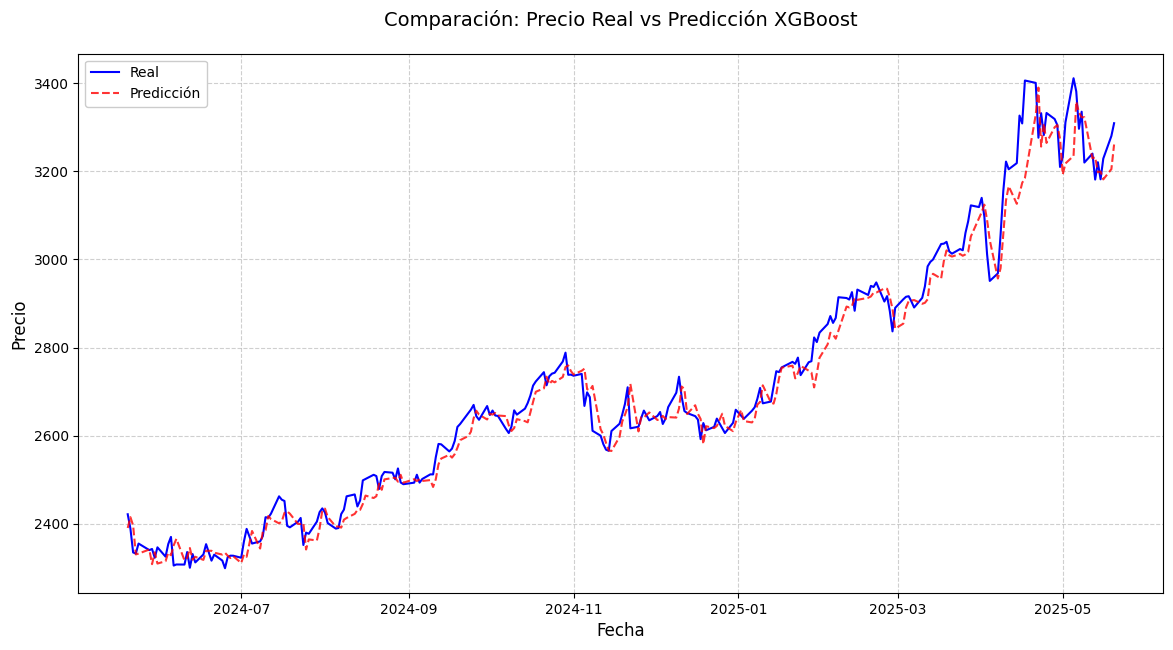

In [ ]:
plot_real_vs_predicted(
    df=resultados_backtest_xgb,
    real_col='Valor_Real',       # Nombre de tu columna real
    pred_col='Predicción',       # Nombre de tu columna de predicciones
    title='Comparación: Precio Real vs Predicción XGBoost',
    real_color='b',        # Azul estándar (o usa 'b')
    pred_color='r',        # Naranja matplotlib (o usa 'orange')
    pred_linestyle='--',         # Estilo de línea para predicciones
    figsize=(14, 7),
    grid=True,                   # Activar cuadrícula
    save_path='GBR_vs_real.png'  # Guardar gráfico
)

In [ ]:
#verificamos el nuevo df con las predicciones
resultados_backtest.iloc[-1000:].head(-5)

,Valor_Real,Predicción
Índice,,
2024-05-20,2421.699951,2379.537954
2024-05-21,2389.199951,2404.468948
2024-05-22,2335.000000,2393.543953
2024-05-23,2332.500000,2344.185981
2024-05-24,2355.199951,2343.762981
...,...,...
2025-05-07,3296.600098,3326.489961
2025-05-08,3335.399902,3301.130010
2025-05-09,3220.000000,3315.244988


In [ ]:
def backtest_strategy_simple(prediction_df, original_df):

    # --- PASO 1: Preparar DataFrames ---
    prediction_df = prediction_df.sort_index()
    original_df = original_df.sort_index()

    # Obtener precios relevantes
    close_original = original_df.loc[prediction_df.index, 'Close'].shift(-1)  # Precio día siguiente
    df = prediction_df.assign(
        Close_Original=close_original,
        Valor_Dia_Ant=close_original.shift(1)  # Precio día anterior para señal
    ).dropna()

    # --- PASO 2: Calcular señales y retornos ---
    df['Retorno_Real'] = df['Close_Original'].pct_change()
    df['Señal'] = np.where(
        df['Predicción'] > df['Valor_Dia_Ant'],
        1,  # Comprar
        0    # No operar
    )

    # --- PASO 3: Métricas clave ---
    df['Retorno_Estrategia'] = df['Señal'] * df['Retorno_Real']
    df['Rentabilidad_Acumulada'] = (1 + df['Retorno_Estrategia']).cumprod() - 1

    rentabilidad_final = df['Rentabilidad_Acumulada'].iloc[-1] * 100
    num_operaciones = df['Señal'].sum()
    operaciones_positivas = (df['Retorno_Estrategia'] > 0).sum()
    accuracy = operaciones_positivas / num_operaciones if num_operaciones > 0 else 0

    # --- RESULTADOS ---
    print(f"\n=== RESULTADOS BACKTESTING ===")
    print(f"Rentabilidad Final: {rentabilidad_final:.2f}%")
    print(f"Número de Operaciones: {num_operaciones}")
    print(f"Operaciones Positivas: {operaciones_positivas}")
    print(f"Accuracy: {accuracy:.2%}")

    return {
        'rentabilidad': rentabilidad_final,
        'operaciones': num_operaciones,
        'accuracy': accuracy,
        'df_resultados': df[['Close_Original', 'Valor_Real', 'Predicción', 'Valor_Dia_Ant',
                            'Señal', 'Retorno_Real', 'Retorno_Estrategia', 'Rentabilidad_Acumulada']]
    }

In [ ]:

resultados_xgb = backtest_strategy_simple(
    prediction_df=resultados_backtest_xgb,
    original_df=oro_xgb
)

# Acceder a los datos como en tu versión:
print(resultados_xgb['df_resultados'].tail())


=== RESULTADOS BACKTESTING ===
Rentabilidad Final: 16.95%
Número de Operaciones: 78
Operaciones Positivas: 50
Accuracy: 64.10%
            Close_Original   Valor_Real   Predicción  Valor_Dia_Ant  Señal  \
2025-05-13     3181.399902  3181.399902  3232.390786    3240.300049      0   
2025-05-14     3220.699951  3220.699951  3197.928517    3181.399902      1   
2025-05-15     3182.000000  3182.000000  3199.626431    3220.699951      0   
2025-05-16     3228.899902  3228.899902  3181.754719    3182.000000      0   
2025-05-19     3280.300049  3280.300049  3205.049087    3228.899902      0   

            Retorno_Real  Retorno_Estrategia  Rentabilidad_Acumulada  
2025-05-13     -0.018177           -0.000000                0.155268  
2025-05-14      0.012353            0.012353                0.169539  
2025-05-15     -0.012016           -0.000000                0.169539  
2025-05-16      0.014739            0.000000                0.169539  
2025-05-19      0.015919            0.000000    

In [ ]:
print(model_xgb)

GradientBoostingRegressor(max_depth=5, min_samples_split=5, n_estimators=50,
                          random_state=42)


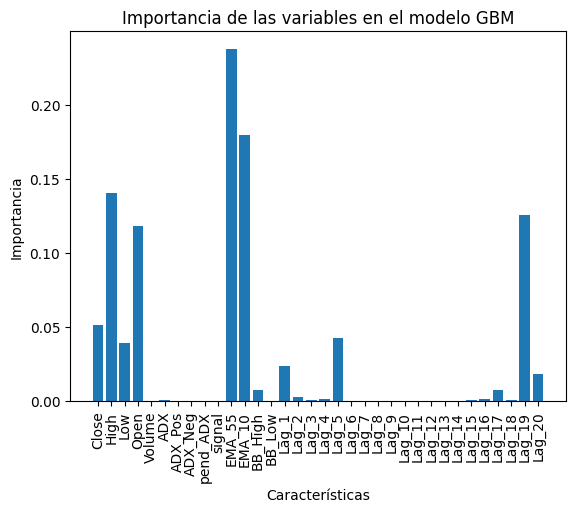

In [ ]:
# Obtenemos el mejor modelo y la lista de variables predictoras
feature_names = X_xgb_train.columns

# Obtenemos la importancia de c/u
importancia = model_xgb.feature_importances_

# Graficamos
plt.bar(range(len(importancia)), importancia)
plt.xticks(range(len(importancia)), feature_names, rotation=90)
plt.xlabel('Características')
plt.ylabel('Importancia')
plt.title('Importancia de las variables en el modelo GBM')
plt.savefig('importancia_variables.png')
plt.show()

# Redes Neuronales Modelo LSTM


## Sin Indicadores

In [ ]:
import tensorflow as tf
import keras
from keras import Model
from keras.layers import Input, Dense, Dropout
from keras.layers import LSTM
from tensorflow.keras.regularizers import L2 # Import L2 regularizer
from tensorflow.keras.losses import Huber
import plotly.express as px
import tensorflow as tf
import math
from scipy.stats import pearsonr


In [ ]:
#cramos una copia del DF scaled nielsen para utilizar
oro_rn_si = oro_scaled_Nielsen.copy()

In [ ]:
oro_rn_si.head()

Price,Close,Open,High,Low,Volume,Return,DailyVolatility,ScaledVolatility,ScaledReturn,ScaledVolume
Date,,,,,,,,,,
2000-09-05,275.799988,275.799988,275.799988,275.799988,2,0.0,0.0,-0.487191,-0.487191,1.399270
2000-09-06,274.200012,274.200012,274.200012,274.200012,0,0.0,0.0,-0.426635,-0.426635,-0.465213
2000-09-07,274.000000,274.000000,274.000000,274.000000,125,0.0,0.0,-0.381686,-0.381686,1.841310
2000-09-08,273.299988,273.299988,273.299988,273.299988,0,0.0,0.0,-0.346452,-0.346452,-0.413957
2000-09-11,273.100006,273.100006,273.100006,273.100006,0,0.0,0.0,-0.317772,-0.317772,-0.377947


In [ ]:
#cramos una funcion para graficar
def graficar_oro(df, fecha_inicio, fecha_fin, df_1=None):
  mask = (df.index >= fecha_inicio) & (df.index <= fecha_fin)
  df = df.loc[mask]
  plt.figure(figsize=(15, 8))
  plt.plot(df.index, df['Close'], label='Precio del Oro', color='black', linewidth=1.5)
  if df_1 is not None:
    plt.plot(df_1.index, df_1['Close'], label='Precio del Oro 2', color='red', linewidth=1.5)
  plt.xlabel('Fecha')
  plt.ylabel('Precio (USD)')
  plt.title(f'Precio del Oro ({fecha_inicio} a {fecha_fin})')
  plt.legend()
  plt.grid(True)
  plt.show()

In [ ]:
oro_rn_si.shape

(6200, 10)

In [ ]:
oro_scaled = oro_rn_si[['ScaledReturn', 'ScaledVolume', 'ScaledVolatility']].copy()

In [ ]:
oro_rn_si = oro_rn_si[['ScaledReturn', 'ScaledVolume', 'ScaledVolatility']]
oro_rn_si.head()

Price,ScaledReturn,ScaledVolume,ScaledVolatility
Date,,,
2000-09-05,-0.487191,1.399270,-0.487191
2000-09-06,-0.426635,-0.465213,-0.426635
2000-09-07,-0.381686,1.841310,-0.381686
2000-09-08,-0.346452,-0.413957,-0.346452
2000-09-11,-0.317772,-0.377947,-0.317772


In [ ]:
#Ejecutaremos el proceso en ventanas de 60 periodos, deibo a que se trata de un proceso estocastico tenemos que considerar el pasado
#reciente para la proxima prediccion
window_size = 20

In [ ]:
train_df = oro_rn_si[:5500]
test_df = oro_rn_si[5500:] #para que nos queden 700 datos para backtesting

In [ ]:
test_df.head(-5)

Price,ScaledReturn,ScaledVolume,ScaledVolatility
Date,,,
2022-08-09,0.156856,-0.254701,-0.936531
2022-08-10,-0.750037,-0.233641,0.037582
2022-08-11,-0.416613,-0.203210,-0.774870
2022-08-12,0.837819,-0.233676,-0.008244
2022-08-15,-1.342693,-0.229855,0.809449
...,...,...,...
2025-05-08,-1.720372,-0.201250,1.189613
2025-05-09,0.751496,-0.192906,-0.820916
2025-05-12,-1.384467,-0.133369,1.002947


In [ ]:
horizon = 10
X = train_df[:(5500 - horizon)][["ScaledVolatility", "ScaledReturn",
"ScaledVolume"]].values
Y = train_df[horizon:]["ScaledReturn"].values

In [ ]:
len(Y)

5490

In [ ]:
X.shape

(5490, 3)

In [ ]:
X = np.expand_dims(X, axis = 1)

In [ ]:
X = np.split(X, X.shape[0]/10, axis = 0)
X = np.concatenate(X, axis = 1)
X.shape

(10, 549, 3)

In [ ]:
## architecture parameters
NUM_HIDDEN = 4
NUM_LAYERS = 2

## data formatting parameters
BATCH_SIZE = 64
WINDOW_SIZE = 20

In [ ]:
LEARNING_RATE = 1e-2
EPOCHS = 30

In [ ]:
## python
Xinp = keras.Input(dtype = tf.float32, shape = [WINDOW_SIZE, None, 3])
Yinp = keras.Input(dtype = tf.float32, shape = [None])

In [ ]:


class LSTMModel(tf.keras.Model):
    def __init__(self, num_hidden, num_layers):
        super(LSTMModel, self).__init__()
        self.rnn = tf.keras.layers.RNN(
            tf.keras.layers.StackedRNNCells([
                tf.keras.layers.LSTMCell(num_hidden) for _ in range(num_layers)
            ]),
            return_sequences=True
        )
        # W_fc sin bias, inicializada de forma uniforme como en el original
        self.W_fc = tf.Variable(
            initial_value=tf.random.uniform([num_hidden, 1], minval=-0.2, maxval=0.2),
            trainable=True,
            name='W_fc'
        )

    def call(self, inputs):
        rnn_output = self.rnn(inputs)  # [batch_size, time_steps, num_hidden]
        last_output = rnn_output[:, -1, :]  # último paso temporal
        output = tf.squeeze(tf.matmul(last_output, self.W_fc), axis=-1)  # [batch_size]
        return output

# Crear modelo
model = LSTMModel(num_hidden=NUM_HIDDEN, num_layers=NUM_LAYERS)

# Compilar con pérdida y optimizador equivalentes al original
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=LEARNING_RATE),
    loss='mse'  # tf.nn.l2_loss era equivalente a MSE sin el factor 1/2
)


In [ ]:
# Parámetros
NUM_HIDDEN = 32
NUM_LAYERS = 2
BATCH_SIZE = 32
WINDOW_SIZE = 20
LEARNING_RATE = 0.001
EPOCHS = 10

# Asumiendo que 'train_df' y 'test_df' están definidos y tienen las columnas correctas
FEATURE_COLUMNS = ["ScaledVolatility", "ScaledReturn", "ScaledVolume"]
TARGET_COLUMN = "ScaledReturn"

# Modelo
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WINDOW_SIZE, len(FEATURE_COLUMNS))),
    tf.keras.layers.LSTM(NUM_HIDDEN, return_sequences=True),
    *[tf.keras.layers.LSTM(NUM_HIDDEN, return_sequences=True) for _ in range(NUM_LAYERS - 2)],
    tf.keras.layers.LSTM(NUM_HIDDEN),
    tf.keras.layers.Dense(1)
])

loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# Función para crear ventanas de datos
def create_dataset(df, window_size):
    X, Y = [], []
    data = df[FEATURE_COLUMNS].values
    target = df[TARGET_COLUMN].values
    for i in range(len(df) - window_size):
        X.append(data[i:i+window_size])
        Y.append(target[i+window_size])
    return np.array(X), np.array(Y)

# Crear datasets
X_train, Y_train = create_dataset(train_df, WINDOW_SIZE)
X_test, Y_test = create_dataset(test_df, WINDOW_SIZE)

# Entrenamiento
test_y_hat_dict = {}
test_y_dict = {}
in_sample_Y_dict = {}
in_sample_y_hat_dict = {}

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).batch(BATCH_SIZE)

for ep in range(EPOCHS):
    epoch_training_loss = 0.0
    for X_batch, Y_batch in train_dataset:
        with tf.GradientTape() as tape:
            y_pred = model(X_batch, training=True)
            loss_value = loss_fn(Y_batch, tf.squeeze(y_pred))

        grads = tape.gradient(loss_value, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        epoch_training_loss += loss_value.numpy() * X_batch.shape[0]

        in_sample_Y_dict[ep] = Y_batch.numpy()
        in_sample_y_hat_dict[ep] = y_pred.numpy().squeeze()

    # Evaluación
    y_pred_test = model.predict(X_test, batch_size=BATCH_SIZE)
    testing_loss = loss_fn(Y_test, tf.squeeze(y_pred_test)).numpy()

    print(f"Epoch: {ep+1} Training loss: {epoch_training_loss/len(X_train):.4f} Testing loss: {testing_loss:.4f}")

    test_y_dict[ep] = Y_test
    test_y_hat_dict[ep] = y_pred_test.squeeze()

MAX_EPOCH = EPOCHS - 1


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Epoch: 1 Training loss: 0.7964 Testing loss: 0.8570
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Epoch: 2 Training loss: 0.7917 Testing loss: 0.8546
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Epoch: 3 Training loss: 0.7896 Testing loss: 0.8531
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Epoch: 4 Training loss: 0.7879 Testing loss: 0.8515
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Epoch: 5 Training loss: 0.7864 Testing loss: 0.8504
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Epoch: 6 Training loss: 0.7850 Testing loss: 0.8499
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Epoch: 7 Training loss: 0.7838 Testing loss: 0.8500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Epoch: 8 Training loss: 0.7826 Testing loss: 0.8505
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Epoch: 9 Training loss: 0.7815 Testing loss: 0.8513
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Epoch: 10 Training loss: 0.7804 Testing loss: 0.8523


In [ ]:
## python
pearsonr(test_y_dict[MAX_EPOCH], test_y_hat_dict[MAX_EPOCH])

PearsonRResult(statistic=np.float64(0.14424530620510248), pvalue=np.float64(0.00016046230130245065))

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

def lstm_time_series_cv(
    model, X, y, window_size=20, n_splits=3, epochs=10, batch_size=32, verbose=1
):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = []

    for fold, (train_index, test_index) in enumerate(tscv.split(X)):
        # Crear ventanas temporales
        X_train, y_train = [], []
        for i in range(len(train_index) - window_size):
            X_train.append(X[train_index[i:i+window_size]])
            y_train.append(y[train_index[i+window_size]])
        X_train, y_train = np.array(X_train), np.array(y_train)

        X_test, y_test = [], []
        for i in range(len(test_index) - window_size):
            X_test.append(X[test_index[i:i+window_size]])
            y_test.append(y[test_index[i+window_size]])
        X_test, y_test = np.array(X_test), np.array(y_test)

        # Entrenamiento
        history = model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=epochs,
            batch_size=batch_size,
            verbose=verbose
        )

        # Evaluación (extraer solo el valor de pérdida, no todas las métricas)
        test_loss = model.evaluate(X_test, y_test, verbose=0)[0]  # [0] para obtener solo el MSE
        scores.append(test_loss)
        print(f"Fold {fold + 1} - MSE: {test_loss:.4f}")

    print(f"\nMSE promedio: {np.mean(scores):.4f} (±{np.std(scores):.4f})")
    return scores

In [ ]:
X_cv = train_df[FEATURE_COLUMNS].values  # Todos los datos disponibles
y_cv = train_df[TARGET_COLUMN].values

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
             loss='mse',
             metrics=['mae'])

In [ ]:
cv_scores = lstm_time_series_cv(
    model=model,
    X=X_cv,
    y=y_cv,
    window_size=WINDOW_SIZE,
    n_splits=3,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.7871 - mae: 0.5845 - val_loss: 0.7884 - val_mae: 0.6258
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.7720 - mae: 0.5873 - val_loss: 0.7890 - val_mae: 0.6274
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.7957 - mae: 0.5841 - val_loss: 0.7892 - val_mae: 0.6270
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.8506 - mae: 0.6075 - val_loss: 0.7947 - val_mae: 0.6313
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.7354 - mae: 0.5630 - val_loss: 0.7945 - val_mae: 0.6306
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.7322 - mae: 0.5675 - val_loss: 0.7933 - val_mae: 0.6311
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.7262 - mae: 0.5617 - val_loss: 0.8039 - val_mae: 0.6365
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.7725 - mae: 0.5874 - val_loss: 0.7930 - val_mae: 0.6316
Epoch 9/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.761

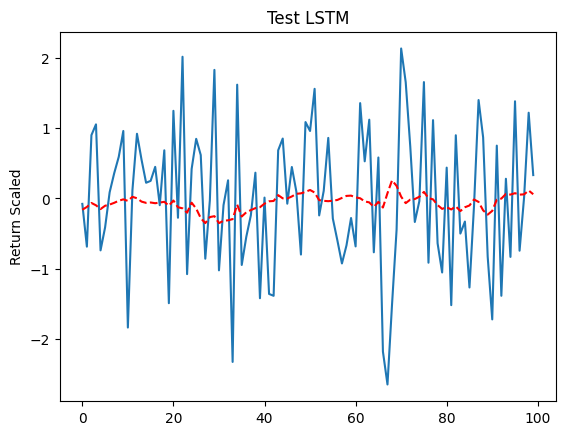

In [ ]:
## python
plt.plot(test_y_dict[MAX_EPOCH][-100:])
plt.plot(test_y_hat_dict[MAX_EPOCH][-100:], 'r--')
plt.ylabel('Return Scaled')
plt.title('Test LSTM')
plt.savefig('test_lstm.png')
plt.show()